# Minimal DESN Real-Time ENSO Forecast

Pipeline:
1. **Data loading** - full 1958-2026 dataset; train/validation split
2. **Hyperparameter configuration**
3. **Train on 1979-present; validate on 1958-1978 as a health check**
4. **Real-time rolling forecast** from the latest available raw timestamp
5. **Save models (optional) and forecast data**


In [73]:
import warnings
warnings.filterwarnings("ignore")

from RCENSO import *
import numpy as np
import pandas as pd
import reservoirpy as rpy
import xarray as xr

rpy.verbosity(0)
%config InlineBackend.figure_format = 'retina'

# --- Global settings ---------------------------------------------------------
DATA_PATH = 'oras5_indices_1958-2026-04.nc'
REALTIME_START = None      # None = use the latest raw timestamp in DATA_PATH
FORECAST_STEPS = 20        # Real-time forecast horizon (months after lead 0)
VALIDATION_STEPS = 20      # Validation health-check leads; lead 0 is analysis
PLOT_MODE = 'Nino34'       # Climate mode to plot in the real-time figure
NMEMBERS_BY_MODEL = {1: 2, 2: 5}  # Members for DESN nl=1 and nl=2
PLOT_HISTORY_MONTHS = 6    # Months before initialisation shown in the plot
SAVE_MODELS = True        # Set True to pickle trained ESNs in the save cell

climate_modes = ['Nino34', 'WWV', 'NPMM', 'SPMM', 'IOB', 'TNA', 'ATL3', 'IOD', 'SIOD', 'SASD']
MONTH_ABBR = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


## 1. Data Loading

Temporal split:
- **Training**: 1979-present, ending at the latest available real-time month
- **Validation**: 1958-1978, used only as a health check that training and forecasting work


In [77]:
def to_month_start(ts):
    return pd.Timestamp(ts).to_period('M').to_timestamp()


def resolve_realtime_start(raw_times, requested=None):
    """Use the latest raw timestamp in the requested month."""
    raw_times = pd.DatetimeIndex(raw_times)
    if requested is None:
        return pd.Timestamp(raw_times[-1])

    requested_month = pd.Timestamp(requested).to_period('M')
    latest_month = raw_times[-1].to_period('M')
    if requested_month > latest_month:
        raise ValueError(f'REALTIME_START {requested} is later than latest data month {latest_month}')

    matches = raw_times[raw_times.to_period('M') == requested_month]
    if len(matches) == 0:
        raise ValueError(f'No raw data found for real-time month {requested_month}')
    return pd.Timestamp(matches[-1])


_ds = xr.open_dataset(DATA_PATH, engine='netcdf4')
raw_times = pd.DatetimeIndex(convert_to_standard_calendar(_ds.time.values))
REALTIME_START = resolve_realtime_start(raw_times, REALTIME_START).strftime('%Y-%m-%d')
train_end = to_month_start(REALTIME_START)

ds_full = standardize_time_to_month_start(_ds)
ds_full = ds_full[['Nino34', 'WWV'] + [v for v in ds_full.data_vars if v not in ('Nino34', 'WWV')]]
mode_names = list(ds_full.data_vars)

train_ds = ds_full.sel(time=slice('1979-01-01', train_end.strftime('%Y-%m-%d')))
val_ds = ds_full.sel(time=slice('1958-01-01', '1978-12-01'))

TS_train = train_ds.to_array().values.T
TS_val = val_ds.to_array().values.T
tl = TS_train.shape[0]

print(f"Full raw data   : {raw_times[0]:%Y-%m-%d} to {raw_times[-1]:%Y-%m-%d} ({ds_full.time.size} months)")
print(f"Training months : {pd.Timestamp(train_ds.time.values[0]):%Y-%m} to {pd.Timestamp(train_ds.time.values[-1]):%Y-%m} ({tl} months)")
print(f"Validation      : {pd.Timestamp(val_ds.time.values[0]):%Y-%m} to {pd.Timestamp(val_ds.time.values[-1]):%Y-%m} ({TS_val.shape[0]} months)")
print(f"Real-time start : {REALTIME_START}")


Full raw data   : 1958-01-16 to 2026-04-16 (820 months)
Training months : 1979-01 to 2026-04 (568 months)
Validation      : 1958-01 to 1978-12 (252 months)
Real-time start : 2026-04-16


## 2. Hyperparameter Configuration

Default DESN hyperparameters from the paper. No tuning or validation-based member selection is used in this simple real-time workflow.


In [60]:
model_types = [r'DESN($n_l=1$)', r'DESN($n_l=2$)']

hypers = {
    model_types[0]: {
        'units': 20000,
        'lr': 1,
        'sr': 1,
        'rc_connectivity': 0.0,
        'input_connectivity': 0.10,
        'input_scaling': 1,
        'ridge': 5e-6,
        'noise_rc': 0.05,
        'noise_in': 0,
        'output_dim': TS_train.shape[1],
        'seed': None,
        'use_raw_input': True,
        'ip_reservoir': True,
    },
    model_types[1]: {
        'units': [20000, 12000],
        'lr': [1, 1],
        'sr': [1, 1],
        'rc_connectivity': [0, 0],
        'input_connectivity': [0.1, 0.1],
        'input_scaling': [1, 1],
        'ridge': 5e-6,
        'noise_rc': [0.05, 0],
        'noise_in': [0, 0],
        'output_dim': TS_train.shape[1],
        'seed': None,
        'deep': True,
        'deep_ip_list': [True, False],
    },
}

print("Default hyperparameters loaded.")

Default hyperparameters loaded.


## 3. Train DESN Ensemble on 1979-Present and Validate on 1958-1978


In [61]:
trained_models = {}
all_models = []

for nl, model_type in zip(NMEMBERS_BY_MODEL, model_types):
    nmember = NMEMBERS_BY_MODEL[nl]
    print(f"Training {model_type}: {nmember} members ...")
    models, _ = TPRC_Train_Ensemble(TS_train, tl, dl=0, hypers=hypers[model_type], nmember=nmember)
    trained_models[model_type] = models
    all_models.extend({'arch': model_type, 'member': i, 'esn': esn} for i, esn in enumerate(models))

all_esns = [model['esn'] for model in all_models]
print(f"Total DESN members used in forecast: {len(all_esns)}")

TP_val = get_RCTP(TS_val, steps=VALIDATION_STEPS, omega=2*np.pi/12, order=2, bias=0)
Ytest_val = np.hstack((TS_val, TP_val[:-VALIDATION_STEPS]))
val_pred_mean, val_member_preds = TPRC_Forecast_Ensemble(
    all_esns, TS_val, TP_test=TP_val, steps=VALIDATION_STEPS, noise_ini=0.0)
val_corr, val_rmse = ndforecast_skill(val_pred_mean, Ytest_val, showdim=0, ismv3=True, wl=0)

if not np.all(np.isfinite(val_corr[1:])) or not np.all(np.isfinite(val_rmse[1:])):
    raise RuntimeError('Validation health check failed: non-finite skill values detected.')

check_leads = [lead for lead in (1, 6, 12) if lead < VALIDATION_STEPS]
summary = ', '.join(f"lead {lead}: corr={val_corr[lead]:.3f}, rmse={val_rmse[lead]:.3f}" for lead in check_leads)
print(f"Validation health check passed ({PLOT_MODE}, 1958-1978): {summary}")


Training DESN($n_l=1$): 2 members ...


Training ensemble members: 100%|██████████| 2/2 [01:10<00:00, 35.27s/it]


Training DESN($n_l=2$): 5 members ...


Training ensemble members:   0%|          | 0/5 [00:00<?, ?it/s]

Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


...

Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Training ensemble members: 100%|██████████| 5/5 [11:16<00:00, 135.21s/it]


Total DESN members used in forecast: 7


Forecasting with ensemble: 100%|██████████| 7/7 [07:21<00:00, 63.08s/it]

Validation health check passed (Nino34, 1958-1978): lead 1: corr=0.980, rmse=0.147, lead 6: corr=0.733, rmse=0.562, lead 12: corr=0.534, rmse=0.824


## 4. Real-Time Rolling Forecast from Latest Time Point

In [62]:
def realtime_forecast(models, x0, TP_rt, t0, forecast_steps):
    """Run one rolling forecast from x0 with all trained DESN members."""
    forecasts = []

    for model in models:
        esn = model['esn']
        member_forecast = [x0.copy()]
        x = np.hstack((x0.reshape(1, -1), TP_rt[t0 - 1].reshape(1, -1)))

        for lead in range(1, forecast_steps + 1):
            y = esn.run(x)
            member_forecast.append(y[0].copy())
            x = np.hstack((y, TP_rt[t0 - 1 + lead].reshape(1, -1)))

        forecasts.append(member_forecast)

    forecasts = np.asarray(forecasts)
    return forecasts, forecasts.mean(axis=0), forecasts.std(axis=0)


In [63]:
forecast_start = to_month_start(REALTIME_START)
ds_full_to_latest = ds_full.sel(time=slice('1979-01-01', forecast_start.strftime('%Y-%m-%d')))
TS_full = ds_full_to_latest.to_array().values.T
x0 = TS_full[-1].copy()
TP_rt = get_RCTP(TS_full, steps=FORECAST_STEPS, omega=2*np.pi/12, order=2, bias=0)

member_preds, rt_mean, rt_std = realtime_forecast(all_models, x0, TP_rt, len(TS_full), FORECAST_STEPS)
forecast_times = pd.date_range(forecast_start, periods=FORECAST_STEPS + 1, freq='MS')

print(f'forecast initialized from raw data date {REALTIME_START}')
print(f'monthly forecast axis from {forecast_times[0]:%Y-%m} to {forecast_times[-1]:%Y-%m}')


forecast initialized from raw data date 2026-04-16
monthly forecast axis from 2026-04 to 2027-12


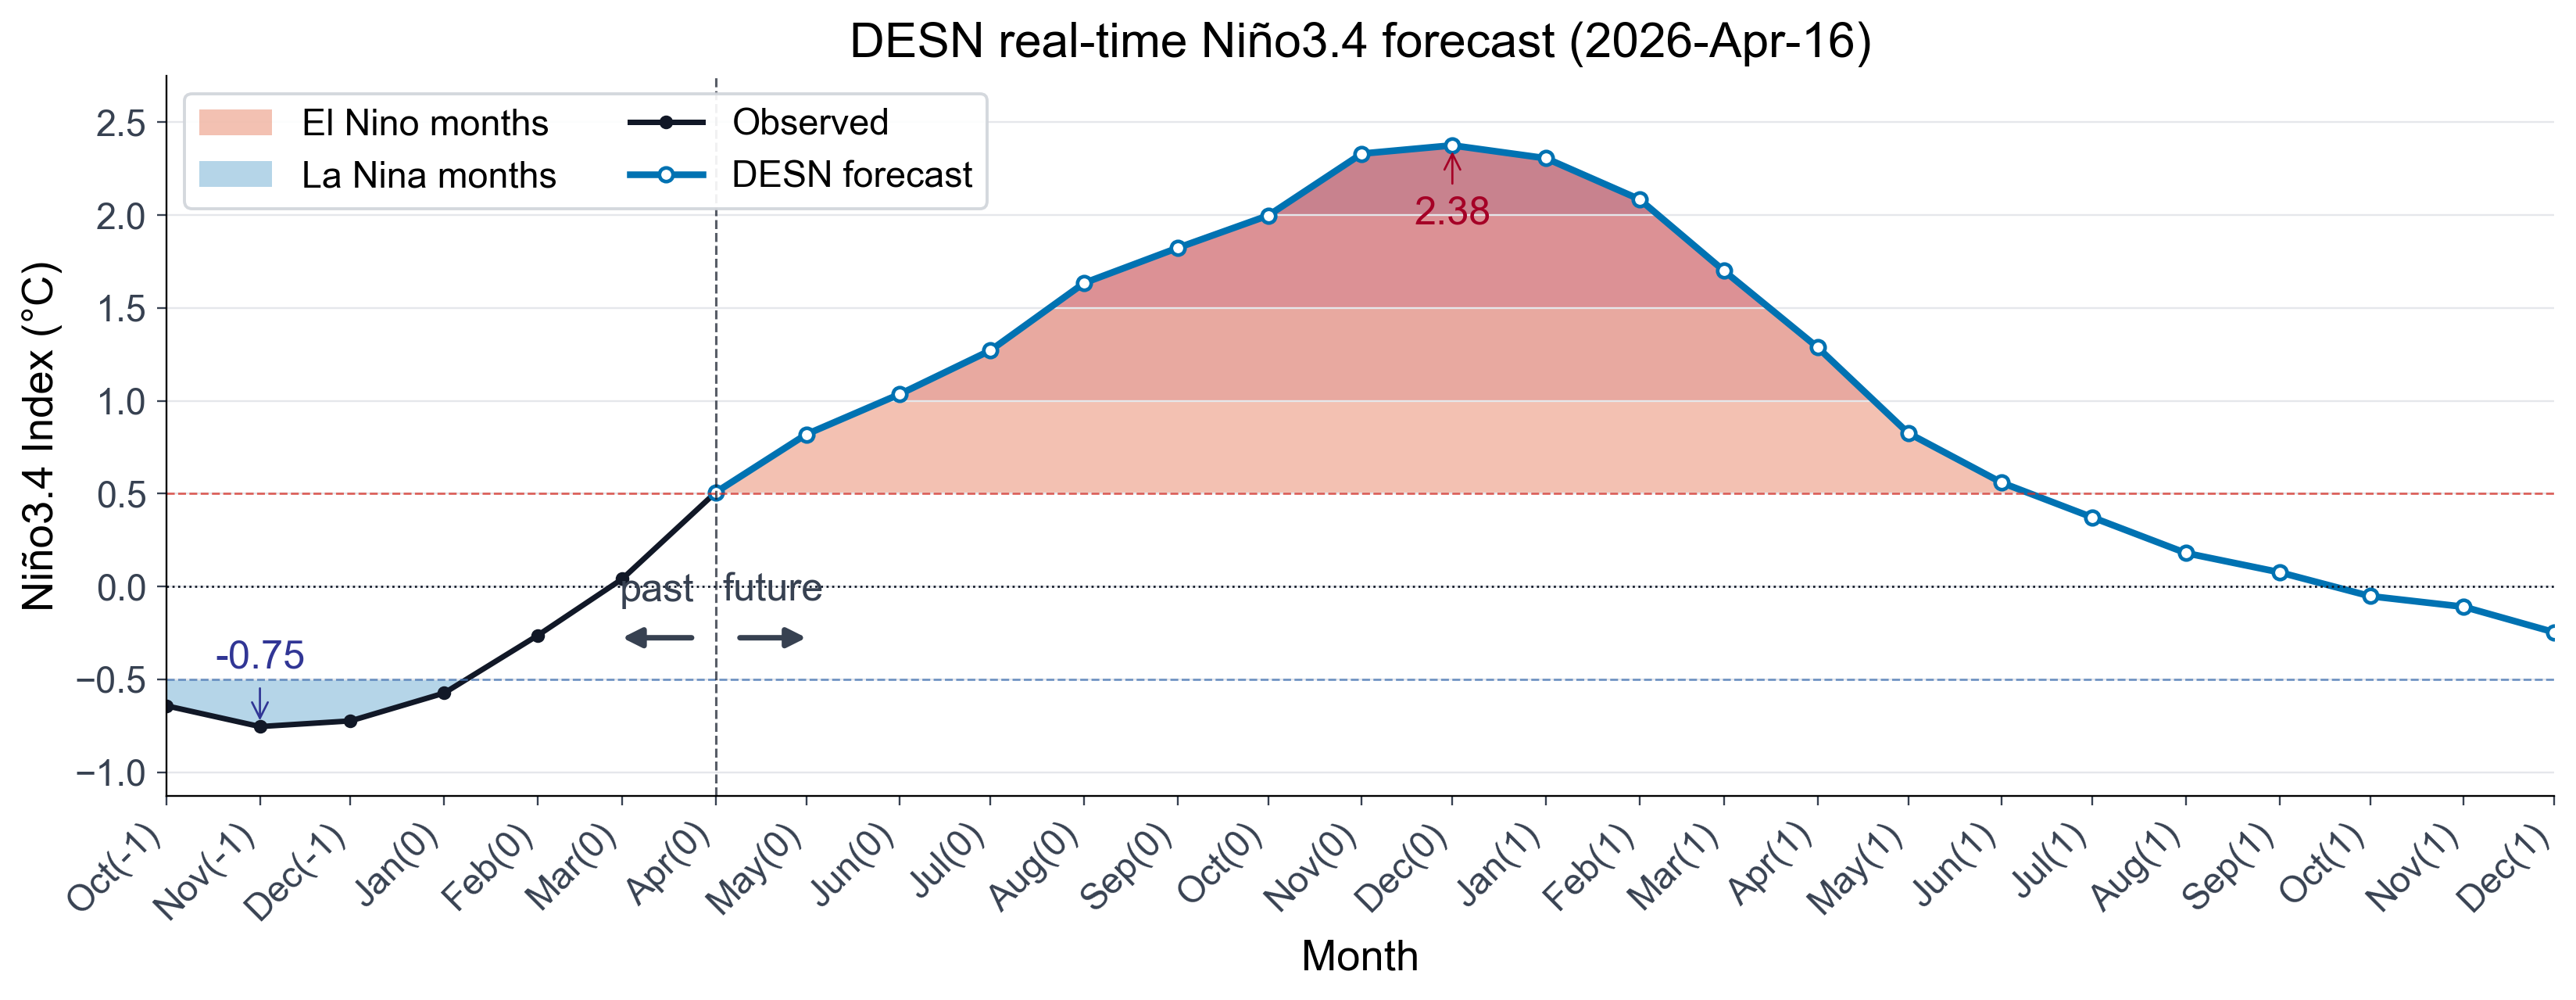

In [72]:
import matplotlib.pyplot as plt


def month_year_label(ts, base_month):
    return f"{MONTH_ABBR[ts.month - 1]}({ts.year - base_month.year})"


def date_label(ts):
    ts = pd.Timestamp(ts)
    return f"{ts.year}-{MONTH_ABBR[ts.month - 1]}-{ts.day:02d}"


def densify_time_series(times, values, freq='D'):
    dense_times = pd.date_range(times[0], times[-1], freq=freq)
    dense_values = np.interp(dense_times.asi8, times.asi8, values)
    return dense_times, dense_values


def anomaly_color(cmap, value, scale):
    signed = np.clip(value / scale, -1, 1)
    norm = 0.5 + 0.5 * np.sign(signed) * (0.35 + 0.65 * abs(signed))
    return cmap(np.clip(norm, 0, 1))


def shade_enso_lanina(ax, times, values, alpha=0.52):
    dense_times, dense_values = densify_time_series(times, values)
    cmap = plt.get_cmap('RdBu_r')
    scale = max(2.5, np.nanmax(np.abs(values)))

    for i, lower in enumerate(np.arange(0.5, max(0.5, np.nanmax(dense_values)) + 0.5, 0.5)):
        upper = lower + 0.5
        ax.fill_between(
            dense_times, lower, np.minimum(dense_values, upper), where=dense_values >= lower,
            color=anomaly_color(cmap, lower, scale), alpha=alpha, linewidth=0,
            label='El Nino months' if i == 0 else None)

    for i, upper in enumerate(-np.arange(0.5, max(0.5, abs(np.nanmin(dense_values))) + 0.5, 0.5)):
        lower = upper - 0.5
        ax.fill_between(
            dense_times, np.maximum(dense_values, lower), upper, where=dense_values <= upper,
            color=anomaly_color(cmap, upper, scale), alpha=alpha, linewidth=0,
            label='La Nina months' if i == 0 else None)


def annotate_extreme(ax, times, values, mask, pick, color, prefer='above'):
    if not np.any(mask):
        return

    masked_idx = np.where(mask)[0]
    idx = masked_idx[pick(values[masked_idx])]
    value = values[idx]
    ylim_low, ylim_high = ax.get_ylim()
    yrange = ylim_high - ylim_low
    margin = 0.08 * yrange
    gap = 0.07 * yrange

    if prefer == 'above':
        text_y = value + gap
        va = 'bottom'
        if text_y > ylim_high - margin:
            text_y = max(value - gap, ylim_low + margin)
            va = 'top'
    else:
        text_y = value - gap
        va = 'top'
        if text_y < ylim_low + margin:
            text_y = min(value + gap, ylim_high - margin)
            va = 'bottom'

    ha = 'center'
    if idx == 0:
        ha = 'left'
    elif idx == len(times) - 1:
        ha = 'right'

    ax.annotate(
        f'{value:.2f}', xy=(times[idx], value), xytext=(times[idx], text_y),
        textcoords='data', ha=ha, va=va, fontsize=13, color=color,
        arrowprops=dict(arrowstyle='->', color=color, linewidth=0.7, shrinkA=2, shrinkB=2))


def add_past_future_arrows(ax, base_month, ylim_low, ylim_high):
    yrange = ylim_high - ylim_low
    arrow_y = ylim_low + yrange * 0.22
    label_y = arrow_y + yrange * 0.04
    past_start, past_end = base_month - pd.DateOffset(months=1), base_month - pd.DateOffset(days=8)
    future_start, future_end = base_month + pd.DateOffset(days=8), base_month + pd.DateOffset(months=1)

    arrow_style = dict(arrowstyle='-|>', color='#374151', linewidth=1.8, mutation_scale=13, shrinkA=0, shrinkB=0)
    ax.annotate('', xy=(past_start, arrow_y), xytext=(past_end, arrow_y), arrowprops=arrow_style)
    ax.annotate('', xy=(future_end, arrow_y), xytext=(future_start, arrow_y), arrowprops=arrow_style)
    ax.text(past_start + (past_end - past_start) / 2, label_y, 'past', ha='center', va='bottom', fontsize=13, color='#374151')
    ax.text(future_start + (future_end - future_start) / 2, label_y, 'future', ha='center', va='bottom', fontsize=13, color='#374151')


def envelope_percentile_band(member_values, percentile_band):
    envelope_min = np.nanmin(member_values, axis=0)
    envelope_max = np.nanmax(member_values, axis=0)
    lo_pct, hi_pct = np.asarray(percentile_band) / 100
    span = envelope_max - envelope_min
    return envelope_min + span * lo_pct, envelope_min + span * hi_pct


def plot_realtime_forecast(ds_history, TS_history, forecast_mean, forecast_times,
                           start, mode_names, plot_mode='Nino34', history_months=6,
                           member_forecasts=None, percentile_band=None, shade_events=True,
                           title=None):
    start = pd.Timestamp(start)
    base_month = to_month_start(start)
    mode_idx = mode_names.index(plot_mode)
    if title is None:
        title = f'DESN real-time Ni\u00f1o3.4 forecast({date_label(start)})'

    hist_times = pd.DatetimeIndex(pd.to_datetime(ds_history.time.values))[-(history_months + 1):]
    hist_vals = TS_history[-len(hist_times):, mode_idx]
    past_mask = hist_times < base_month

    plot_times = hist_times[past_mask].append(forecast_times)
    mean_vals = np.concatenate([hist_vals[past_mask], forecast_mean[:, mode_idx]])
    y_vals = mean_vals.copy()

    band = None
    if member_forecasts is not None and percentile_band is not None:
        lo, hi = envelope_percentile_band(member_forecasts[:, :, mode_idx], percentile_band)
        band = (lo, hi)
        y_vals = np.concatenate([y_vals, lo, hi])

    fig, ax = plt.subplots(figsize=(12, 4.8), dpi=140)
    if shade_events:
        shade_enso_lanina(ax, plot_times, mean_vals)

    if band is not None:
        ax.fill_between(
            forecast_times, band[0], band[1], color='#0072B2', alpha=0.16, linewidth=0,
            label=f'Ensemble plume')

    ax.plot(hist_times, hist_vals, color='#111827', linewidth=1.8, marker='o', markersize=3.5, label='Observed')
    ax.plot(forecast_times, forecast_mean[:, mode_idx], color='#0072B2', linewidth=2.2,
            marker='o', markersize=4.5, markerfacecolor='white', markeredgewidth=1.2,
            label='DESN forecast')

    ax.axhline(0, color='#111827', linewidth=0.7, linestyle=':')
    ax.axhline(0.5, color='#d73027', linewidth=0.7, linestyle='--', alpha=0.75)
    ax.axhline(-0.5, color='#4575b4', linewidth=0.7, linestyle='--', alpha=0.75)
    ax.axvline(base_month, color='#111827', linewidth=0.8, linestyle='--', alpha=0.7)

    ymin, ymax = np.nanmin(y_vals), np.nanmax(y_vals)
    y_pad = max(0.25, 0.12 * (ymax - ymin if ymax > ymin else 1.0))
    ax.set_ylim(ymin - y_pad, ymax + y_pad)
    add_past_future_arrows(ax, base_month, ymin - y_pad, ymax + y_pad)

    annotate_extreme(ax, plot_times, mean_vals, mean_vals >= 0.5, np.argmax, '#a50026', 'above')
    annotate_extreme(ax, plot_times, mean_vals, mean_vals <= -0.5, np.argmin, '#313695', 'below')

    tick_times = pd.date_range(plot_times[0], plot_times[-1], freq='MS')
    ax.set_xticks(tick_times)
    ax.set_xticklabels([month_year_label(ts, base_month) for ts in tick_times], rotation=45, ha='right', fontsize=12)

    ax.set_title(title, fontsize=16)
    ax.set_ylabel('Ni\u00f1o3.4 Index (\u00b0C)', fontsize=14)
    ax.set_xlabel('Month', fontsize=14)
    ax.set_xlim(plot_times[0], plot_times[-1])
    # ax.margins(x=0)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(0.6)
    ax.tick_params(axis='both', width=0.6, length=3, colors='#374151', labelsize=12)
    ax.grid(axis='y', color='#e5e7eb', linewidth=0.6)
    ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#d1d5db', framealpha=0.92, ncol=2, fontsize=12)

    plt.tight_layout()
    return fig, ax


main_title = f'DESN real-time Ni\u00f1o3.4 forecast ({date_label(REALTIME_START)})'

fig, ax = plot_realtime_forecast(
    ds_full_to_latest, TS_full, rt_mean, forecast_times,
    REALTIME_START, mode_names, plot_mode=PLOT_MODE, history_months=PLOT_HISTORY_MONTHS,
    title=main_title)
plt.show()


## 5. Save Models (Optional) and Forecast Data


In [82]:
import os
import pickle

forecast_start = to_month_start(REALTIME_START)
SAVE_DIR = f'desn_forecast_{forecast_start:%Y-%m}'
os.makedirs(SAVE_DIR, exist_ok=True)

n_members = len(all_models)
member_ids = [f"{model['arch']}#{model['member']}" for model in all_models]
meta = {
    'member_ids': member_ids,
    'n_members': n_members,
    'model_types': model_types,
    'n_members_by_model': NMEMBERS_BY_MODEL,
    'train_period': f"1979-01 to {forecast_start:%Y-%m}",
    'validation_period': '1958-01 to 1978-12',
    'forecast_start': REALTIME_START,
    'forecast_steps': FORECAST_STEPS,
    'validation_steps': VALIDATION_STEPS,
    'validation_nino34_corr': val_corr.tolist(),
    'validation_nino34_rmse': val_rmse.tolist(),
}

meta_path = os.path.join(SAVE_DIR, 'desn_forecast_metadata.pkl')
with open(meta_path, 'wb') as f:
    pickle.dump(meta, f)
print(f"Saved metadata -> {meta_path}")

if SAVE_MODELS:
    models_path = os.path.join('models', f'desn_all_models_{forecast_start:%Y-%m}.pkl')
    with open(models_path, 'wb') as f:
        pickle.dump({'all_models': all_models, 'trained_models': trained_models, 'metadata': meta}, f)
    print(f"Saved trained models -> {models_path}")
else:
    print('Model pickle skipped (SAVE_MODELS=False).')

forecast_ds = xr.Dataset(
    {
        'forecast_mean': xr.DataArray(
            rt_mean, dims=['time', 'mode'],
            attrs={'description': f'Ensemble mean of all {n_members} DESN members', 'units': 'standardized anomaly'}),
        'forecast_std': xr.DataArray(
            rt_std, dims=['time', 'mode'],
            attrs={'description': f'Ensemble standard deviation across all {n_members} DESN members', 'units': 'standardized anomaly'}),
        'forecast_members': xr.DataArray(
            member_preds, dims=['member', 'time', 'mode'],
            attrs={'description': 'Per-member forecasts from all trained DESN members', 'units': 'standardized anomaly'}),
        'validation_nino34_corr': xr.DataArray(
            val_corr, dims=['lead_validation'],
            attrs={'description': 'Nino34 Pearson correlation on validation period; health check only'}),
        'validation_nino34_rmse': xr.DataArray(
            val_rmse, dims=['lead_validation'],
            attrs={'description': 'Nino34 RMSE on validation period; health check only', 'units': 'standardized anomaly'}),
    },
    coords={
        'time': forecast_times.values,
        'mode': mode_names,
        'member': np.arange(n_members),
        'member_id': ('member', member_ids),
        'lead_validation': np.arange(VALIDATION_STEPS),
    },
    attrs={
        'title': 'DESN real-time ENSO forecast',
        'init_month': f"{forecast_start.year}-{MONTH_ABBR[forecast_start.month - 1]}",
        'forecast_start': REALTIME_START,
        'train_period': meta['train_period'],
        'validation_period': meta['validation_period'],
        'model_selection': 'none; all trained members are used',
        'n_members': int(n_members),
    }
)

nc_path = os.path.join(SAVE_DIR, f'desn_forecast_{forecast_start:%Y-%m}.nc')
forecast_ds.to_netcdf(nc_path)
print(f"Saved forecast data -> {nc_path}")
print(forecast_ds)


Saved metadata -> desn_forecast_2026-04\desn_forecast_metadata.pkl
Saved trained models -> models\desn_all_models_2026-04.pkl
Saved forecast data -> desn_forecast_2026-04\desn_forecast_2026-04.nc
<xarray.Dataset> Size: 16kB
Dimensions:                 (time: 21, mode: 10, member: 7, lead_validation: 20)
Coordinates:
  * time                    (time) datetime64[ns] 168B 2026-04-01 ... 2027-12-01
  * mode                    (mode) <U6 240B 'Nino34' 'WWV' ... 'SIOD' 'SASD'
  * member                  (member) int32 28B 0 1 2 3 4 5 6
  * lead_validation         (lead_validation) int32 80B 0 1 2 3 ... 16 17 18 19
    member_id               (member) <U15 420B 'DESN($n_l=1$)#0' ... 'DESN($n...
Data variables:
    forecast_mean           (time, mode) float64 2kB 0.5071 11.27 ... -0.5419
    forecast_std            (time, mode) float64 2kB 0.0 1.776e-15 ... 0.2119
    forecast_members        (member, time, mode) float64 12kB 0.5071 ... -0.4901
    validation_nino34_corr  (lead_validation) flo